**negrito**# Nova seção

# 1: Carregamento e Análise Exploratória de Imagens (EDA)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [1]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")
mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)
print("Finalizou o processo de baixar o dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


In [2]:
X = mnist.data
y = mnist.target

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (70000, 784)
Dimensão de y: (70000,)


In [3]:
import numpy as np

y = y.astype(np.int8)

print("Classes:", np.unique(y))

Classes: [0 1 2 3 4 5 6 7 8 9]


In [5]:

distribuicao = pd.Series(y).value_counts().sort_index()

print(distribuicao)

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


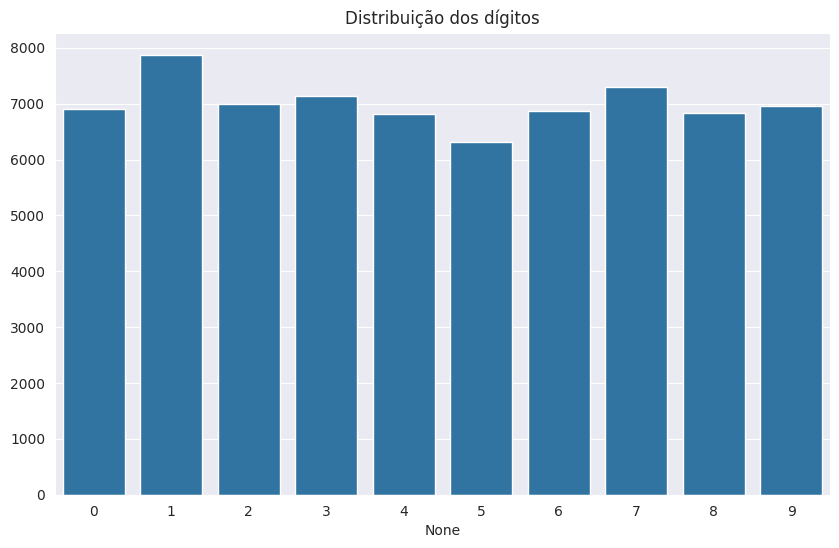

In [10]:
plt.figure(figsize=(10,6))


sns.barplot(x=distribuicao.index, y=distribuicao.values)
plt.title("Distribuição dos dígitos")

plt.show()



*   A distribuição de cada dígito é bem parecida



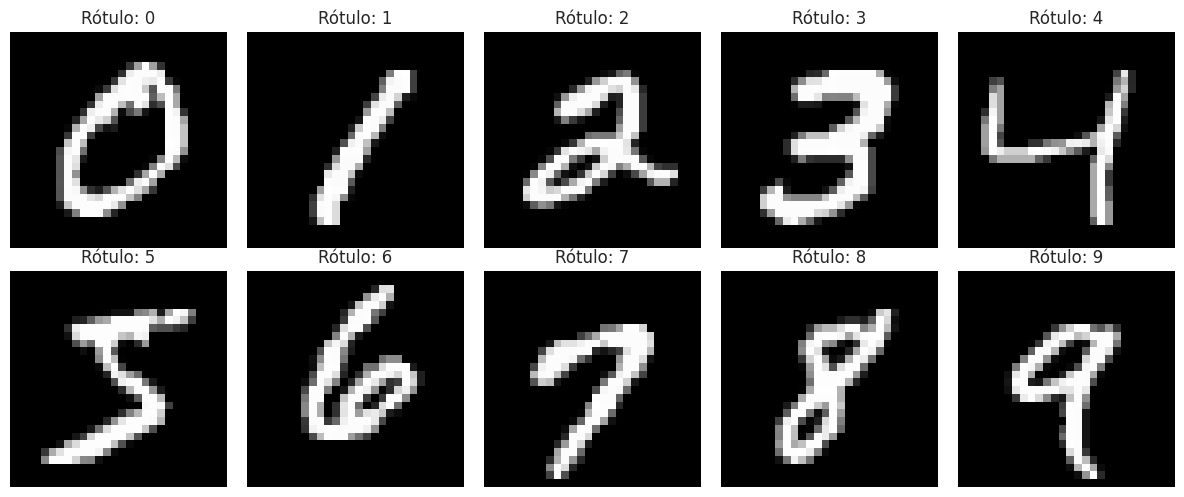

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):
    indice = np.where(y == digito)[0][0]

    imagem = X[indice].reshape(28, 28)

    axes[digito // 5, digito % 5].imshow(
        imagem,
        cmap='gray'
    )

    axes[digito // 5, digito % 5].set_title(f'Rótulo: {y[indice]}')
    axes[digito // 5, digito % 5].axis('off')

plt.tight_layout()
plt.show()



*   O conjunto MNIST é composto por imagens de dígitos manuscritos de 0 a 9. Cada imagem possui dimensão 28 × 28 pixels, totalizando 784 pixels.

*  No conjunto, cada imagem é representada como um vetor de 784 características, no qual cada característica corresponde à intensidade de um pixel, os valores variam de 0 a 255.


*   0 associado ao preto e 255 ao branco, com os valores intermediários representando diferentes tons de cinza. Dessa forma, a transformação de uma imagem 28 × 28 em um vetor de 784 posições permite utilizar algoritmos tradicionais de Machine Learning sobre as imagens.






# 2 Pipeline de Pré-processamento e Divisão dos Dados

## Divisão de treino e teste

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [15]:
X_train.shape

(56000, 784)

In [16]:
X_test.shape

(14000, 784)

## Normalização dos dados

In [18]:
print("Dados originais antes da normalização:")
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

Dados originais antes da normalização:
Valor mínimo: 0
Valor máximo: 255


In [19]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Dados após a normalização:")
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

Dados após a normalização:
Valor mínimo: 0.0
Valor máximo: 1.0





*  Para modelos baseados em distância, a normalização é importante para evitar que características com valores maiores tenham uma influência desproporcional nos cálculos de distância

*  Para modelos de Deep Learning, a normalização ajuda na otimização dos pesos durante o treinamento, tornando o processo de aprendizado mais eficiente e estável.


*   Gradientes mais estáveis: redes neurais são normalmente treinadas por métodos baseados em gradiente. Entradas em escalas muito diferentes podem gerar gradientes desproporcionais, dificultando e tornando mais lento o processo de aprendizado.

*   Funções de ativação: valores de entrada muito grandes podem fazer com que funções como Sigmoid e Tanh entrem em regiões de saturação, nas quais seus gradientes ficam muito pequenos, prejudicando o aprendizado.

*   Inicialização dos pesos: os pesos das redes neurais geralmente começam com valores relativamente pequenos. Entradas normalizadas ajudam a manter as ativações e os cálculos em escalas adequadas, reduzindo problemas numéricos e facilitando o início do treinamento.


